<a href="https://colab.research.google.com/github/8Mune/wine/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%A2%D1%80%D0%B5%D1%84%D0%B8%D0%BB%D0%BE%D0%B2%D0%B0_%D0%95%D0%9A_Wine_Quality_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Дисциплина: "Анализ данных"
## Работу выполнила: Елизавета Трефилова, студентка 2 курса магистратуры, МГИМО, ОП "ИИ"
### Датасет: Wine Quality

---

## Тема 1: Введение в анализ данных

In [ ]:
# 1. Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print("✓ Библиотеки импортированы")

✓ Библиотеки импортированы


In [ ]:
# 2. Загрузка данных из интернета
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print(f"Датасет загружен!")
print(f"Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")

Датасет загружен!
Размер: 1599 строк, 12 столбцов


In [ ]:
# 3. Первые строки данных
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/14Y4ptTWX4g65-J8LMYkD6OFhRaBMlmvP0MSWhxhMv0U/edit#gid=0


In [ ]:
# 4. Информация о данных
print("Типы данных:")
print(df.dtypes)
print("\n" + "="*50)
print("Пропущенные значения:")
print(df.isnull().sum().sum(), "пропусков всего")

Типы данных:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Пропущенные значения:
0 пропусков всего


In [ ]:
# 5. Описательная статистика
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [ ]:
# 6. Работа с данными: фильтрация и добавление столбца
# Добавим категорию качества
df['quality_category'] = pd.cut(df['quality'], bins=[0, 5, 7, 10],
                                labels=['Низкое', 'Среднее', 'Высокое'])

print("Распределение по категориям качества:")
print(df['quality_category'].value_counts())

Распределение по категориям качества:
quality_category
Среднее    837
Низкое     744
Высокое     18
Name: count, dtype: int64


In [ ]:
# 7. Сохранение очищенных данных
df.to_csv('wine_quality_cleaned.csv', index=False)
print("✓ Данные сохранены в wine_quality_cleaned.csv")

✓ Данные сохранены в wine_quality_cleaned.csv


In [ ]:
# 8. Группировка данных (groupby)
grouped = df.groupby('quality_category').agg({
    'alcohol': ['mean', 'std'],
    'volatile acidity': ['mean', 'std'],
    'pH': ['mean', 'std']
}).round(3)

print("Статистики по категориям качества вина:")
grouped

Статистики по категориям качества вина:


alcohol        volatile acidity            pH       
                    mean    std             mean    std   mean    std
quality_category                                                     
Низкое             9.926  0.758            0.590  0.178  3.312  0.154
Среднее           10.828  1.089            0.475  0.162  3.312  0.153
Высокое           12.094  1.224            0.423  0.145  3.267  0.201

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=grouped)

https://docs.google.com/spreadsheets/d/1tBb9mrRnIvNVe4iBhCtmk8FPf5ApItXSiNdfn-CoFEI/edit#gid=0


APIError: APIError: [400]: Invalid values[0][0]: list_value 	 {
  values {
    string_value: "alcohol"
  }
  values {
    string_value: "mean"
  }
}


In [ ]:
# 9. Применение функций (apply)
def alcohol_level(x):
    if x < 10:
        return 'Низкое содержание'
    elif x < 12:
        return 'Среднее содержание'
    else:
        return 'Высокое содержание'

df['alcohol_level'] = df['alcohol'].apply(alcohol_level)
print("Распределение вина по уровню алкоголя:")
print(df['alcohol_level'].value_counts())

Распределение вина по уровню алкоголя:
alcohol_level
Среднее содержание    757
Низкое содержание     680
Высокое содержание    162
Name: count, dtype: int64


In [ ]:
# 10. Сводная таблица (pivot_table)
pivot = pd.pivot_table(df,
                       values='alcohol',
                       index='quality_category',
                       columns='alcohol_level',
                       aggfunc='mean').round(2)

print("Сводная таблица: средний алкоголь по категориям:")
pivot

Сводная таблица: средний алкоголь по категориям:


alcohol_level,Высокое содержание,Низкое содержание,Среднее содержание
quality_category,,,
Низкое,12.82,9.48,10.61
Среднее,12.55,9.48,10.90
Высокое,13.11,9.80,11.24


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=pivot)

---

## Тема 2: Описательный анализ данных

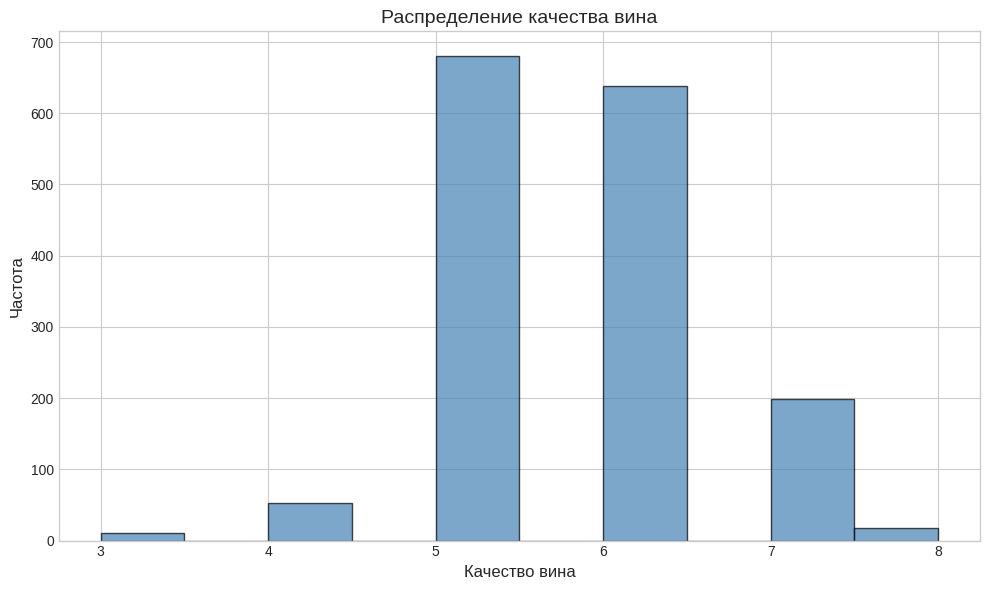

In [ ]:
# 2.1. Гистограмма распределения качества
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['quality'], bins=10, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_xlabel('Качество вина', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)
ax.set_title('Распределение качества вина', fontsize=14)
plt.tight_layout()
plt.show()

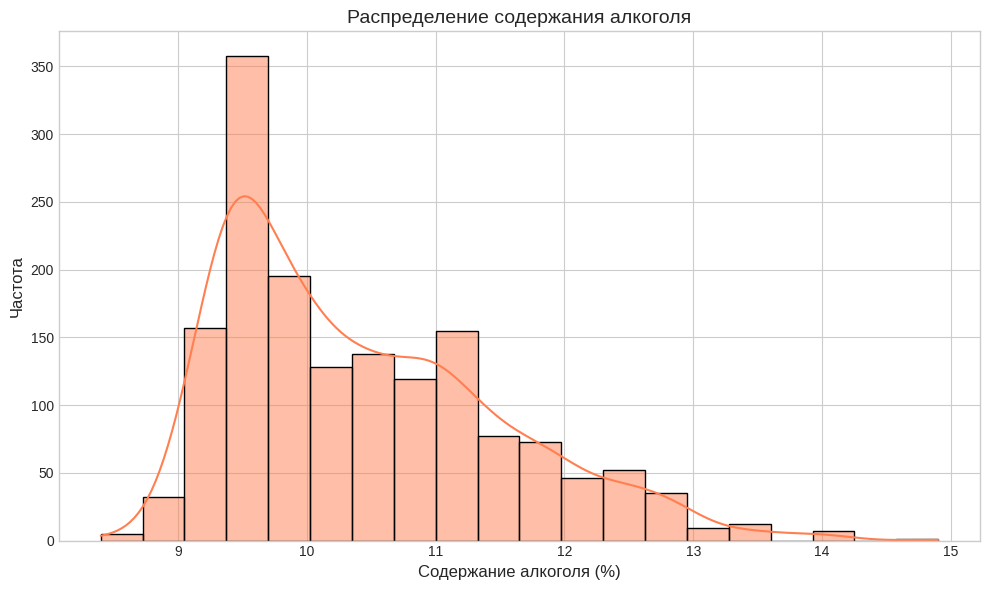

In [ ]:
# 2.2. Гистограмма с KDE (Seaborn)
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['alcohol'], kde=True, ax=ax, color='coral', bins=20)
ax.set_xlabel('Содержание алкоголя (%)', fontsize=12)
ax.set_ylabel('Частота', fontsize=12)
ax.set_title('Распределение содержания алкоголя', fontsize=14)
plt.tight_layout()
plt.show()

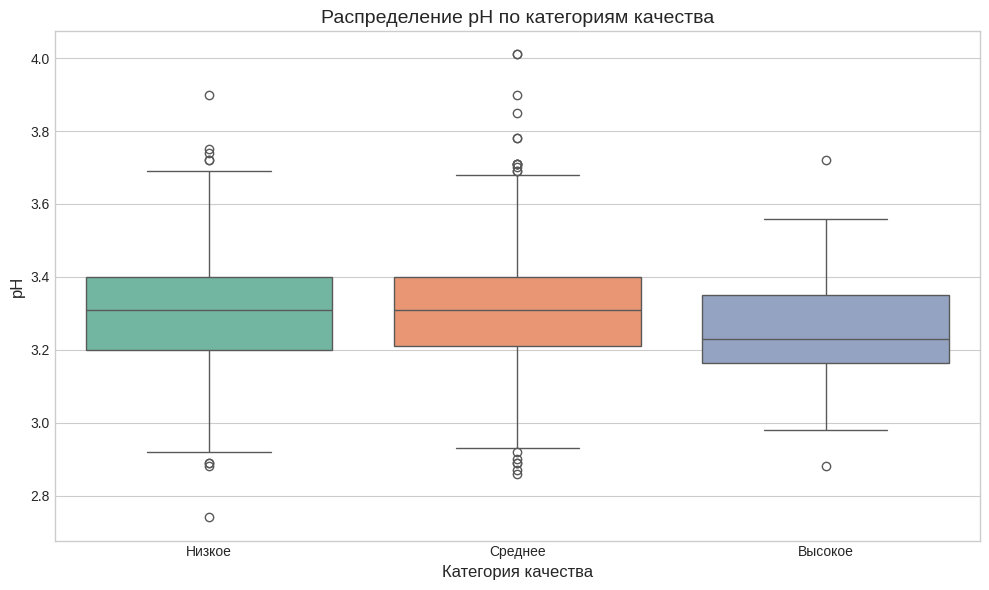

In [ ]:
# 2.3. Boxplot - распределение pH по категориям качества
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(x='quality_category', y='pH', data=df, ax=ax, palette='Set2')
ax.set_xlabel('Категория качества', fontsize=12)
ax.set_ylabel('pH', fontsize=12)
ax.set_title('Распределение pH по категориям качества', fontsize=14)
plt.tight_layout()
plt.show()

TypeError: Data source must be a DataFrame or Mapping, not <class 'module'>.

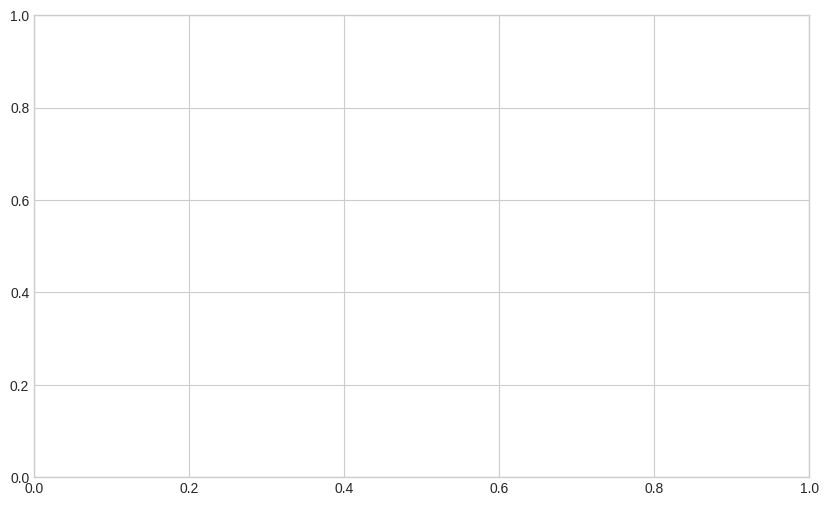

In [ ]:
# 2.4. Violinplot - распределение алкоголя по категориям
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(x='quality_category', y='alcohol', data=df, ax=ax, palette='muted')
ax.set_xlabel('Категория качества', fontsize=12)
ax.set_ylabel('Алкоголь (%)', fontsize=12)
ax.set_title('Распределение алкоголя по категориям качества', fontsize=14)
plt.tight_layout()
plt.show()

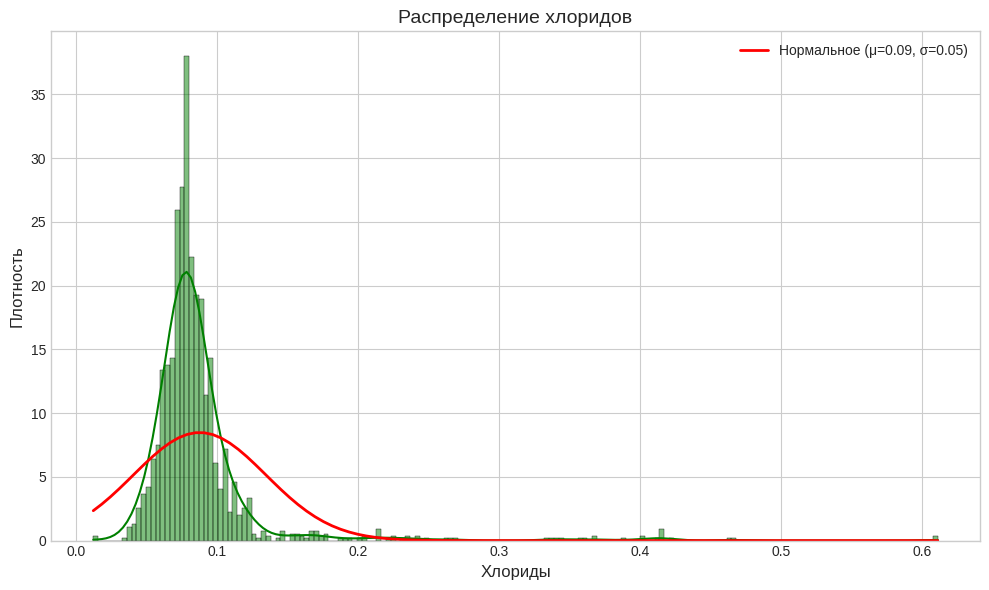

Тест Шапиро-Уилка: statistic=0.4842, p-value=1.1791e-55
Вывод: p < 0.05, распределение НЕ нормальное


In [ ]:
# 2.5. Проверка нормального распределения
from scipy.stats import norm

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['chlorides'], kde=True, ax=ax, stat='density', color='green', alpha=0.5)

mu, std = df['chlorides'].mean(), df['chlorides'].std()
x = np.linspace(df['chlorides'].min(), df['chlorides'].max(), 100)
ax.plot(x, norm.pdf(x, mu, std), 'r-', linewidth=2, label=f'Нормальное (μ={mu:.2f}, σ={std:.2f})')
ax.legend()
ax.set_xlabel('Хлориды', fontsize=12)
ax.set_ylabel('Плотность', fontsize=12)
ax.set_title('Распределение хлоридов', fontsize=14)
plt.tight_layout()
plt.show()

# Тест Шапиро-Уилка
stat, p_value = stats.shapiro(df['chlorides'].dropna()[:5000])
print(f"Тест Шапиро-Уилка: statistic={stat:.4f}, p-value={p_value:.4e}")
print("Вывод: p < 0.05, распределение НЕ нормальное" if p_value < 0.05 else "Вывод: p >= 0.05, нормальное распределение")

In [ ]:
# 2.6. Расширенная описательная статистика
cols = ['quality', 'alcohol', 'volatile acidity', 'sulphates', 'pH']
desc_stats = df[cols].describe()
desc_stats.loc['skew'] = df[cols].skew()
desc_stats.loc['kurtosis'] = df[cols].kurtosis()
print("Расширенная статистика:")
desc_stats.round(3)

Расширенная статистика:


,quality,alcohol,volatile acidity,sulphates,pH
count,1599.000,1599.000,1599.000,1599.000,1599.000
mean,5.636,10.423,0.528,0.658,3.311
std,0.808,1.066,0.179,0.170,0.154
min,3.000,8.400,0.120,0.330,2.740
25%,5.000,9.500,0.390,0.550,3.210
50%,6.000,10.200,0.520,0.620,3.310
75%,6.000,11.100,0.640,0.730,3.400
max,8.000,14.900,1.580,2.000,4.010
skew,0.218,0.861,0.672,2.429,0.194
kurtosis,0.297,0.200,1.226,11.720,0.807


In [ ]:
# 2.7. Частотный анализ
print("Частотный анализ качества вина:")
freq_quality = df['quality'].value_counts().sort_index()
print(freq_quality)

Частотный анализ качества вина:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


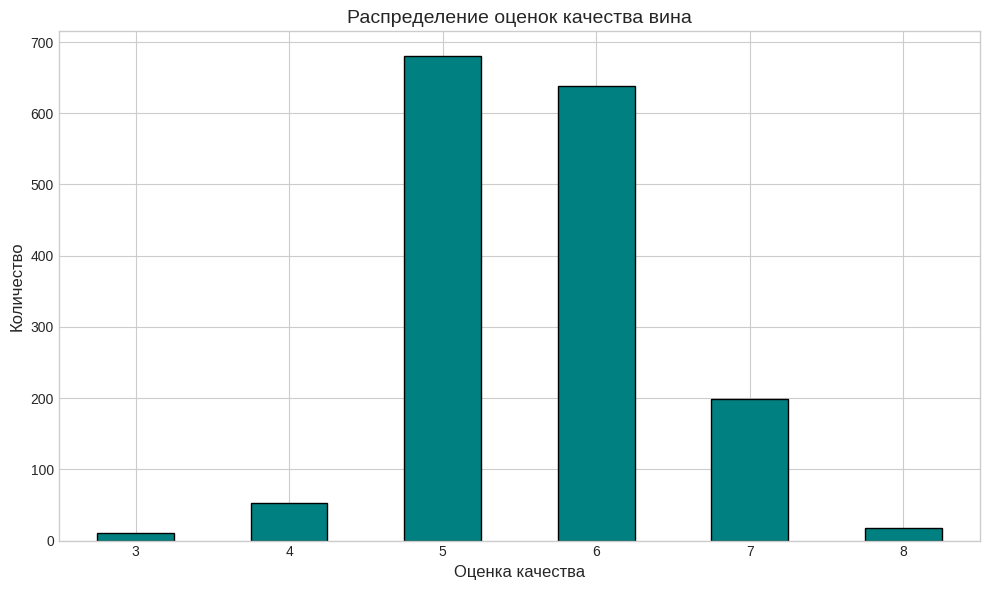

In [ ]:
# 2.8. Столбчатая диаграмма (Bar Chart)
fig, ax = plt.subplots(figsize=(10, 6))
freq_quality.plot(kind='bar', ax=ax, color='teal', edgecolor='black')
ax.set_xlabel('Оценка качества', fontsize=12)
ax.set_ylabel('Количество', fontsize=12)
ax.set_title('Распределение оценок качества вина', fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

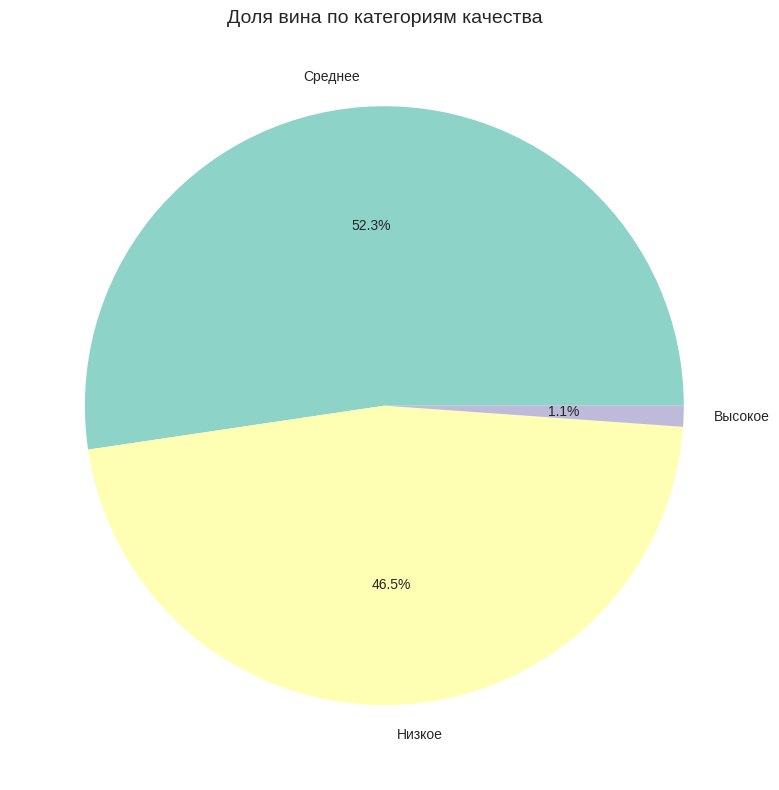

In [ ]:
# 2.9. Круговая диаграмма (Pie Chart)
fig, ax = plt.subplots(figsize=(10, 8))
freq_cat = df['quality_category'].value_counts()
freq_cat.plot(kind='pie', ax=ax, autopct='%1.1f%%', colors=sns.color_palette('Set3'))
ax.set_ylabel('')
ax.set_title('Доля вина по категориям качества', fontsize=14)
plt.tight_layout()
plt.show()

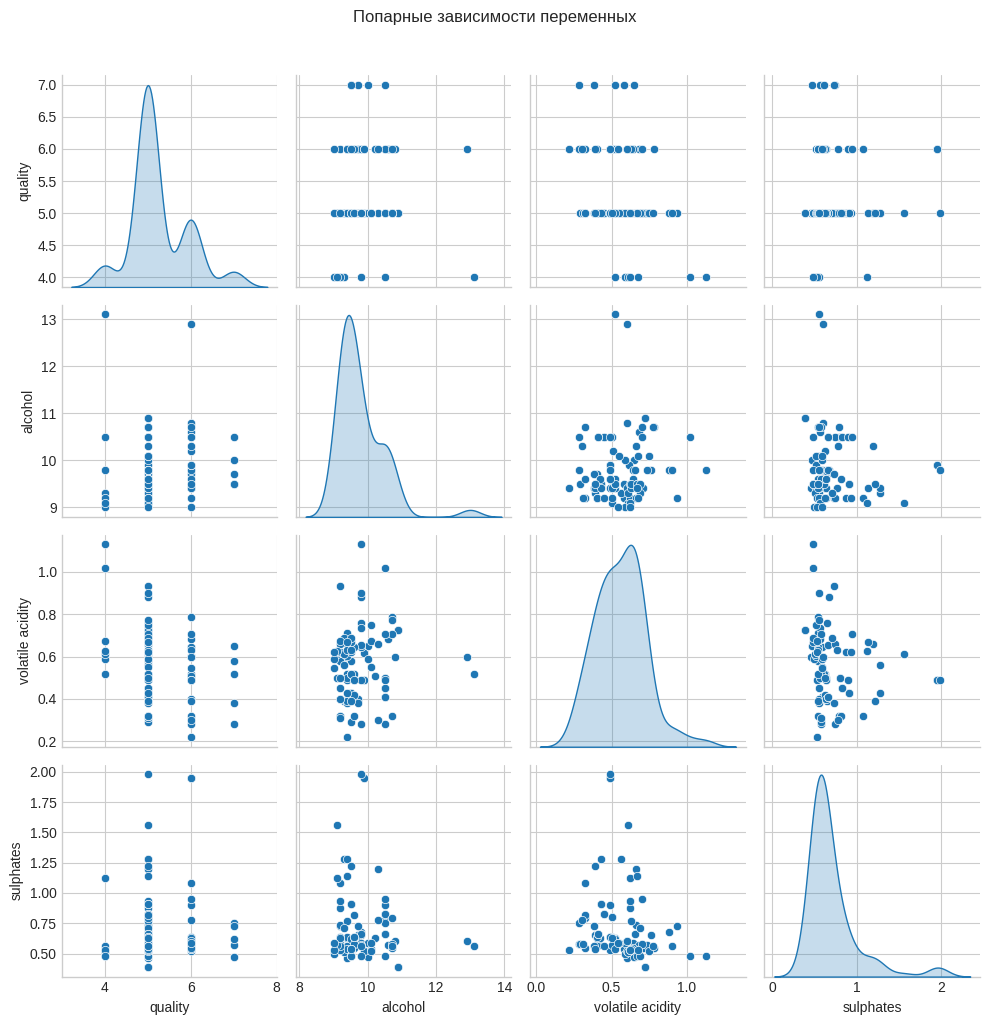

In [ ]:
# 2.10. Pairplot - попарные зависимости
sns.pairplot(df[['quality', 'alcohol', 'volatile acidity', 'sulphates']].head(100),
             diag_kind='kde', palette='husl', corner=False)
plt.suptitle('Попарные зависимости переменных', y=1.02)
plt.tight_layout()
plt.show()

---

## Тема 3: Исследование взаимосвязей между переменными

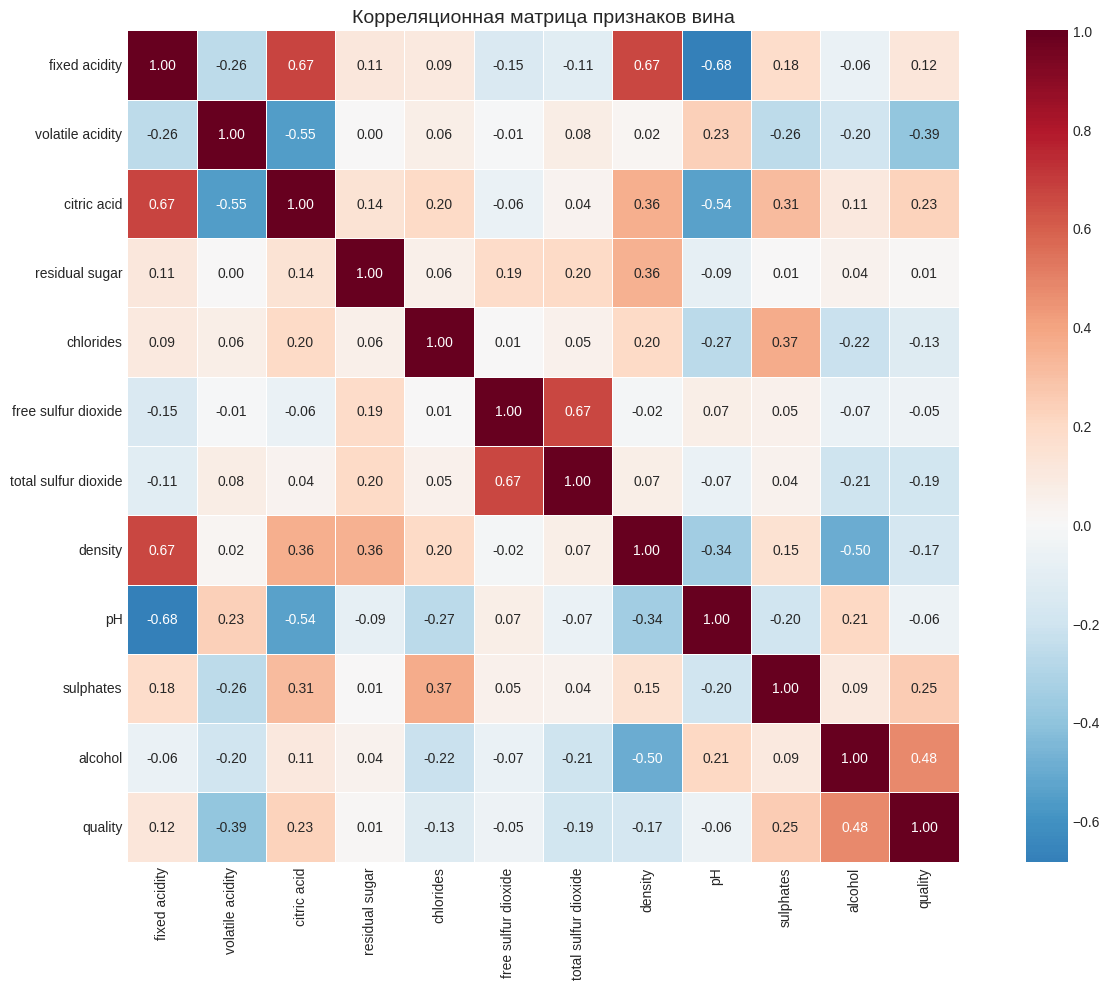

In [ ]:
# 3.1. Корреляционная матрица
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Корреляционная матрица признаков вина', fontsize=14)
plt.tight_layout()
plt.show()

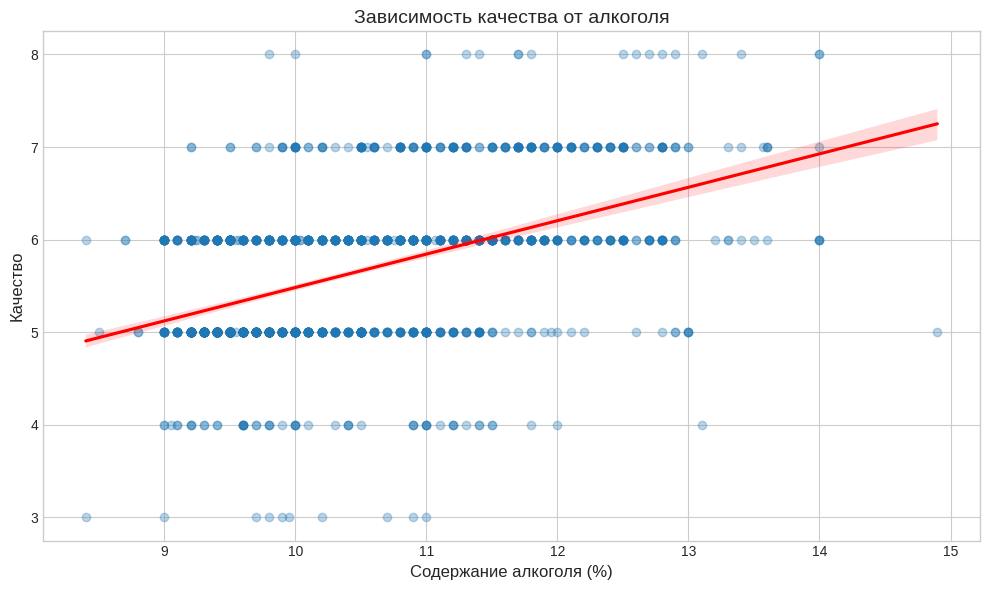

In [ ]:
# 3.2. Scatter plot с линией регрессии
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(x='alcohol', y='quality', data=df, ax=ax,
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
ax.set_xlabel('Содержание алкоголя (%)', fontsize=12)
ax.set_ylabel('Качество', fontsize=12)
ax.set_title('Зависимость качества от алкоголя', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# 3.3. Корреляции Пирсона и Спирмана
pearson_corr, pearson_p = stats.pearsonr(df['alcohol'], df['quality'])
print(f"Корреляция Пирсона: r = {pearson_corr:.4f}, p-value = {pearson_p:.4e}")

spearman_corr, spearman_p = stats.spearmanr(df['alcohol'], df['quality'])
print(f"Корреляция Спирмана: ρ = {spearman_corr:.4f}, p-value = {spearman_p:.4e}")

Корреляция Пирсона: r = 0.4762, p-value = 2.8315e-91
Корреляция Спирмана: ρ = 0.4785, p-value = 2.7268e-92


In [ ]:
# 3.4. Таблица сопряженности
contingency_table = pd.crosstab(df['quality_category'], df['alcohol_level'])
print("Таблица сопряженности: Качество x Уровень алкоголя")
contingency_table

Таблица сопряженности: Качество x Уровень алкоголя


alcohol_level,Высокое содержание,Низкое содержание,Среднее содержание
quality_category,,,
Низкое,14,476,254
Среднее,139,203,495
Высокое,9,1,8


In [ ]:
# 3.5. Тест хи-квадрат
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Тест хи-квадрат:")
print(f"  Хи-квадрат статистика: {chi2:.4f}")
print(f"  p-value: {p_chi2:.4e}")
print(f"  Степени свободы: {dof}")
print(f"\nВывод: {'Связь статистически значима' if p_chi2 < 0.05 else 'Связь не значима'} (p < 0.05)")

Тест хи-квадрат:
  Хи-квадрат статистика: 316.9073
  p-value: 2.4383e-67
  Степени свободы: 4

Вывод: Связь статистически значима (p < 0.05)


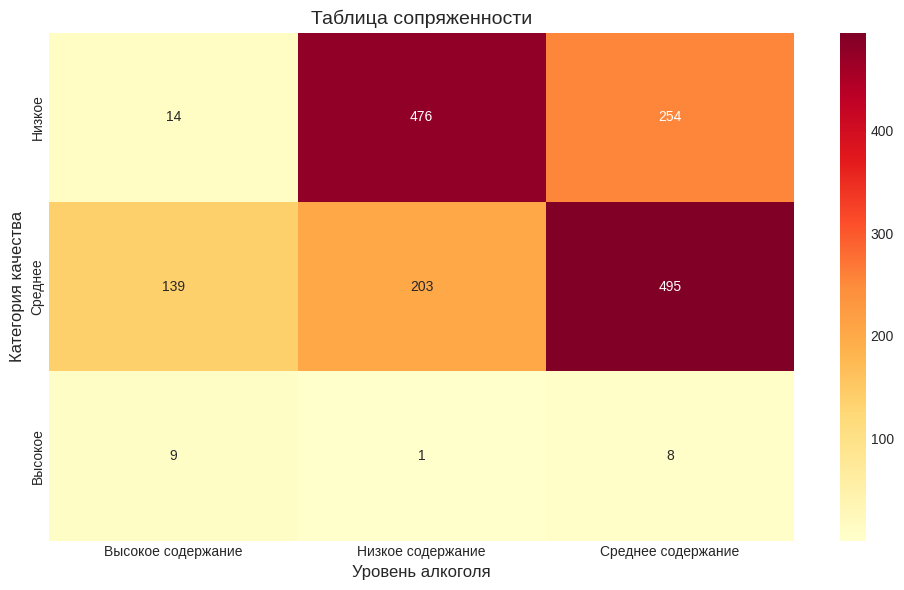

In [ ]:
# 3.6. Тепловая карта таблицы сопряженности
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_xlabel('Уровень алкоголя', fontsize=12)
ax.set_ylabel('Категория качества', fontsize=12)
ax.set_title('Таблица сопряженности', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# 3.7. Независимый t-тест
high_alcohol = df[df['alcohol_level'] == 'Высокое содержание']['quality']
low_alcohol = df[df['alcohol_level'] == 'Низкое содержание']['quality']

t_stat, t_pvalue = stats.ttest_ind(high_alcohol, low_alcohol)
print(f"Среднее качество (высокий алкоголь): {high_alcohol.mean():.2f}")
print(f"Среднее качество (низкий алкоголь): {low_alcohol.mean():.2f}")
print(f"\nT-тест: t = {t_stat:.4f}, p-value = {t_pvalue:.4e}")
print(f"Вывод: {'Различие значимо' if t_pvalue < 0.05 else 'Различие не значимо'}")

Среднее качество (высокий алкоголь): 6.42
Среднее качество (низкий алкоголь): 5.27

T-тест: t = 20.7924, p-value = 8.6967e-78
Вывод: Различие значимо


In [ ]:
# 3.8. Дисперсионный анализ (ANOVA)
quality_groups = [group['quality'].values for name, group in df.groupby('quality_category')]
f_stat, anova_p = stats.f_oneway(*quality_groups)
print(f"ANOVA: F = {f_stat:.4f}, p-value = {anova_p:.4e}")
print("\nСреднее качество по категориям:")
print(df.groupby('quality_category')['quality'].mean().round(2))

ANOVA: F = 2703.3159, p-value = 0.0000e+00

Среднее качество по категориям:
quality_category
Низкое     4.90
Среднее    6.24
Высокое    8.00
Name: quality, dtype: float64


In [ ]:
# 3.9. Непараметрические тесты
# Тест Манна-Уитни
u_stat, u_pvalue = stats.mannwhitneyu(high_alcohol, low_alcohol, alternative='two-sided')
print(f"Тест Манна-Уитни: U = {u_stat:.4f}, p-value = {u_pvalue:.4e}")

# Тест Краскела-Уоллиса
h_stat, kruskal_p = stats.kruskal(*quality_groups)
print(f"Тест Краскела-Уоллиса: H = {h_stat:.4f}, p-value = {kruskal_p:.4e}")

Тест Манна-Уитни: U = 95394.5000, p-value = 1.5468e-58
Тест Краскела-Уоллиса: H = 1408.9354, p-value = 1.1313e-306


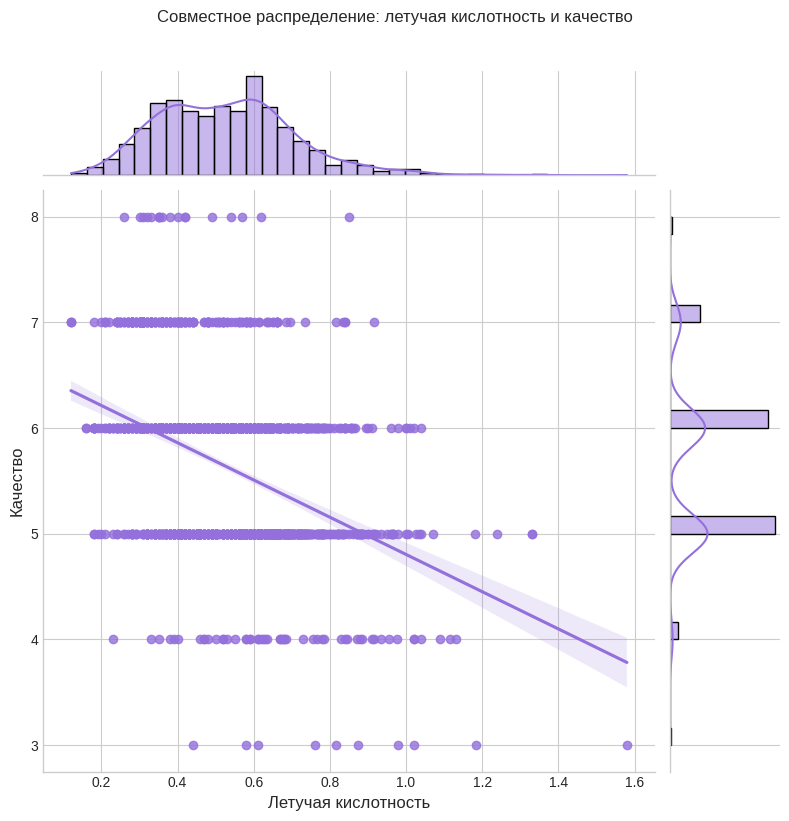

In [ ]:
# 3.10. Jointplot - совместный график
g = sns.jointplot(x='volatile acidity', y='quality', data=df, kind='reg',
                 height=8, ratio=5, color='mediumpurple')
g.ax_joint.set_xlabel('Летучая кислотность', fontsize=12)
g.ax_joint.set_ylabel('Качество', fontsize=12)
plt.suptitle('Совместное распределение: летучая кислотность и качество', y=1.02)
plt.tight_layout()
plt.show()

---

## Тема 4: Регрессия

In [ ]:
# 4.1. Простая линейная регрессия
X = df[['alcohol']].values
y = df['quality'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Простая линейная регрессия (alcohol -> quality):")
print(f"  Коэффициент наклона: {model.coef_[0]:.4f}")
print(f"  Свободный член: {model.intercept_:.4f}")
print(f"  Уравнение: quality = {model.coef_[0]:.4f} * alcohol + {model.intercept_:.4f}")

Простая линейная регрессия (alcohol -> quality):
  Коэффициент наклона: 0.3623
  Свободный член: 1.8493
  Уравнение: quality = 0.3623 * alcohol + 1.8493


In [ ]:
# 4.2. Метрики оценки качества
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Метрики качества модели:")
print(f"  MSE: {mse:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAE: {mae:.4f}")
print(f"  R²: {r2:.4f}")
print(f"\nМодель объясняет {r2*100:.1f}% дисперсии")

Метрики качества модели:
  MSE: 0.4995
  RMSE: 0.7068
  MAE: 0.5750
  R²: 0.2356

Модель объясняет 23.6% дисперсии


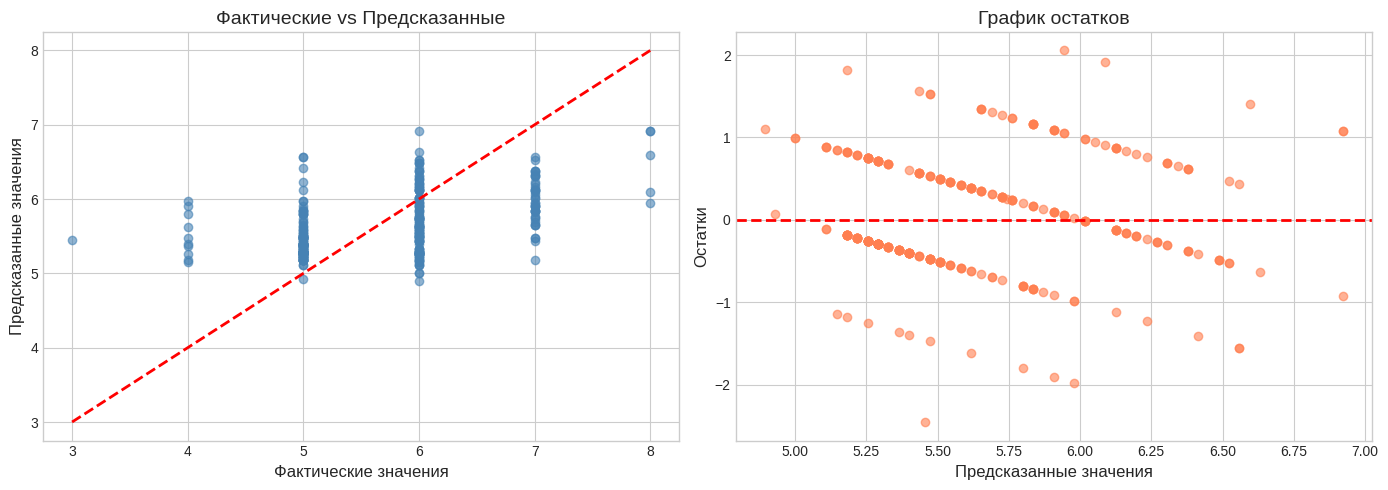

In [ ]:
# 4.3. Визуализация регрессии
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Фактические vs Предсказанные
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Фактические значения', fontsize=12)
axes[0].set_ylabel('Предсказанные значения', fontsize=12)
axes[0].set_title('Фактические vs Предсказанные', fontsize=14)

# Остатки
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='coral')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Предсказанные значения', fontsize=12)
axes[1].set_ylabel('Остатки', fontsize=12)
axes[1].set_title('График остатков', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# 4.4. Множественная линейная регрессия
features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']
X_multi = df[features].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)
y_pred_m = model_multi.predict(X_test_m)

print("Множественная линейная регрессия:")
print("\nКоэффициенты:")
for feat, coef in zip(features, model_multi.coef_):
    print(f"  {feat}: {coef:.4f}")
print(f"\nСвободный член: {model_multi.intercept_:.4f}")

Множественная линейная регрессия:

Коэффициенты:
  alcohol: 0.3106
  volatile acidity: -1.1918
  sulphates: 0.6343
  citric acid: -0.0615

Свободный член: 2.6187


In [ ]:
# 4.5. Множественная регрессия (statsmodels OLS)
X_sm = df[features]
X_sm = sm.add_constant(X_sm)
y_sm = df['quality']

model_sm = sm.OLS(y_sm, X_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                quality   R-squared:                       0.336
Model:                            OLS   Adj. R-squared:                  0.334
Method:                 Least Squares   F-statistic:                     201.8
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          4.22e-140
Time:                        13:56:24   Log-Likelihood:                -1599.1
No. Observations:                1599   AIC:                             3208.
Df Residuals:                    1594   BIC:                             3235.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.6459      0.201  

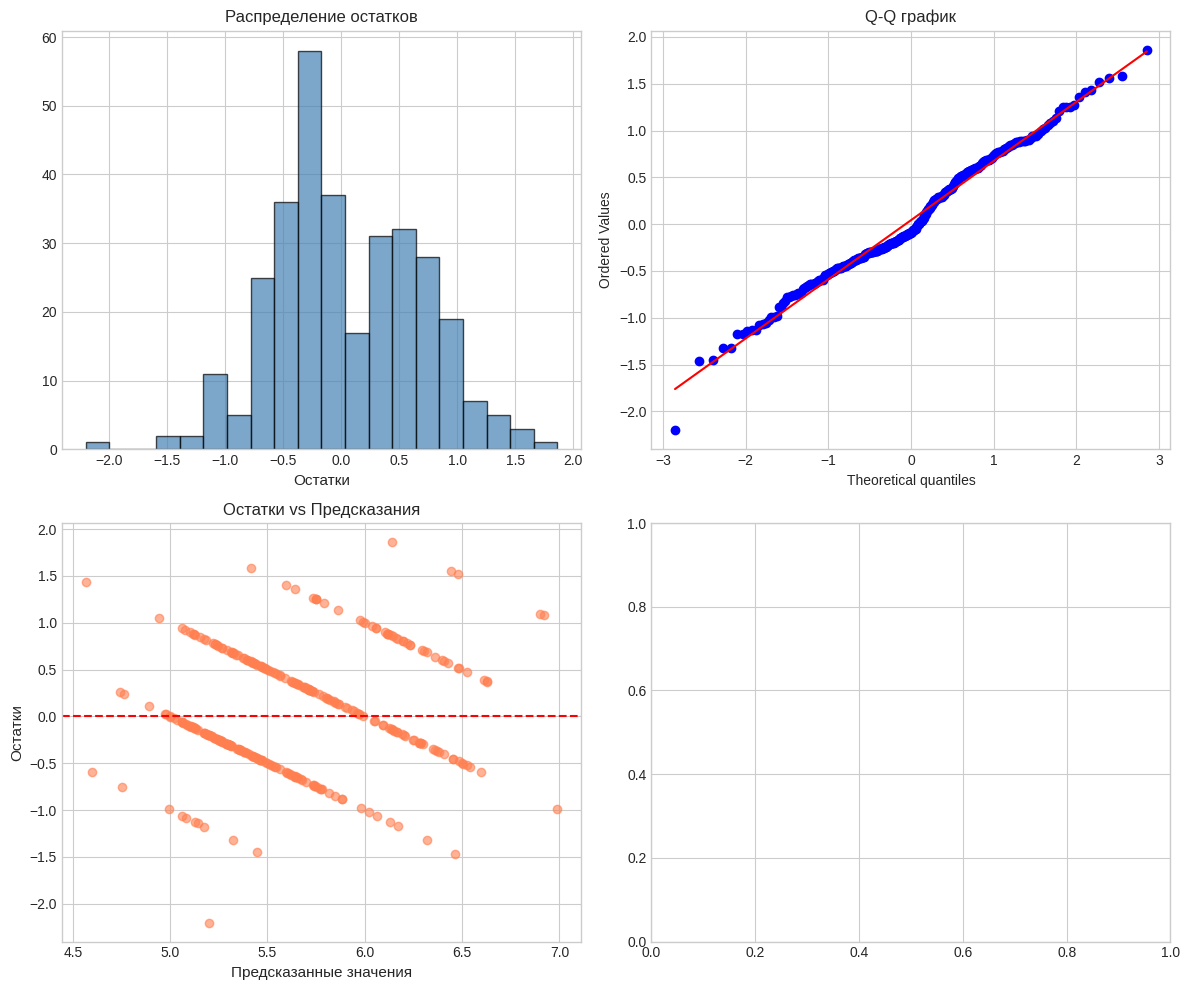

Тест Шапиро-Уилка на нормальность остатков: p = 0.0084


In [ ]:
# 4.6. Анализ остатков
residuals_m = y_test_m - y_pred_m

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Гистограмма остатков
axes[0, 0].hist(residuals_m, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Остатки', fontsize=11)
axes[0, 0].set_title('Распределение остатков', fontsize=12)

# Q-Q plot
stats.probplot(residuals_m, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q график', fontsize=12)

# Остатки vs предсказанные
axes[1, 0].scatter(y_pred_m, residuals_m, alpha=0.6, color='coral')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Предсказанные значения', fontsize=11)
axes[1, 0].set_ylabel('Остатки', fontsize=11)
axes[1, 0].set_title('Остатки vs Предсказания', fontsize=12)

plt.tight_layout()
plt.show()

# Тест на нормальность остатков
stat_res, p_res = stats.shapiro(residuals_m)
print(f"Тест Шапиро-Уилка на нормальность остатков: p = {p_res:.4f}")

In [ ]:
# 4.7. Проверка мультиколлинеарности (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[features]
X_vif = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Переменная'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data[vif_data['Переменная'] != 'const']

print("Фактор инфляции дисперсии (VIF):")
print("(VIF > 10 указывает на мультиколлинеарность)")
print(vif_data.to_string(index=False))

Фактор инфляции дисперсии (VIF):
(VIF > 10 указывает на мультиколлинеарность)
      Переменная      VIF
         alcohol 1.044752
volatile acidity 1.498365
       sulphates 1.124597
     citric acid 1.505652


In [ ]:
# 4.8. Сравнение моделей
from sklearn.preprocessing import StandardScaler

results = {}

# Модель 1: Только alcohol
X1 = df[['alcohol']].values
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y, test_size=0.2, random_state=42)
m1 = LinearRegression().fit(X1_train, y1_train)
pred1 = m1.predict(X1_test)
results['Только alcohol'] = {'R2': r2_score(y1_test, pred1), 'RMSE': np.sqrt(mean_squared_error(y1_test, pred1))}

# Модель 2: Все признаки
X2 = df[features].values
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)
m2 = LinearRegression().fit(X2_train, y2_train)
pred2 = m2.predict(X2_test)
results['Все признаки'] = {'R2': r2_score(y2_test, pred2), 'RMSE': np.sqrt(mean_squared_error(y2_test, pred2))}

# Модель 3: Масштабированные признаки
scaler = StandardScaler()
X3_scaled = scaler.fit_transform(X2)
X3_train, X3_test, y3_train, y3_test = train_test_split(X3_scaled, y, test_size=0.2, random_state=42)
m3 = LinearRegression().fit(X3_train, y3_train)
pred3 = m3.predict(X3_test)
results['Масштабированные'] = {'R2': r2_score(y3_test, pred3), 'RMSE': np.sqrt(mean_squared_error(y3_test, pred3))}

comparison = pd.DataFrame(results).T
print("Сравнение моделей:")
print(comparison.round(4))

Сравнение моделей:
                      R2    RMSE
Только alcohol    0.2356  0.7068
Все признаки      0.3876  0.6326
Масштабированные  0.3876  0.6326


Полиномиальная регрессия (степень 2):
  R²: 0.2316
  RMSE: 0.7086


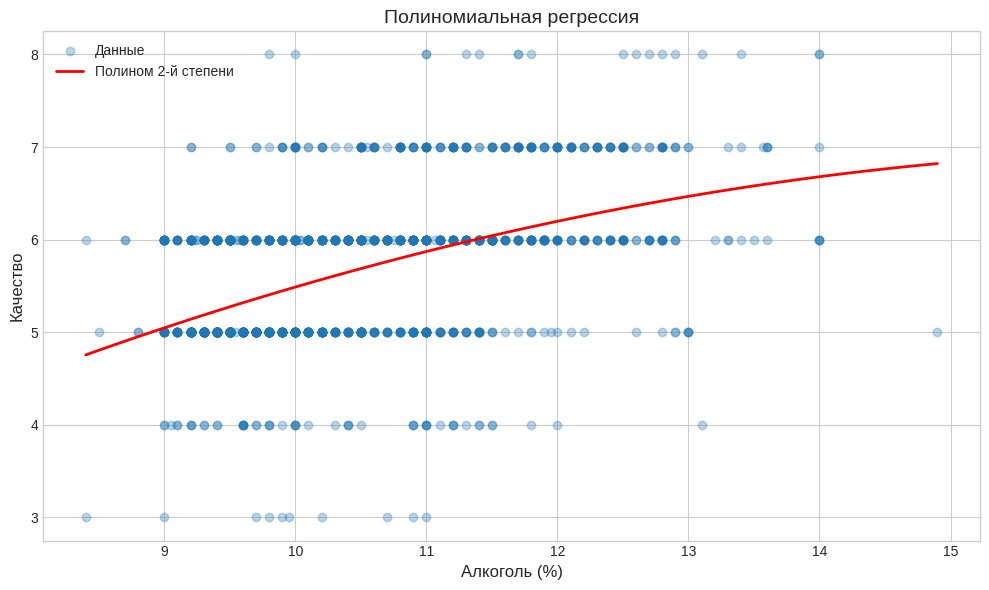

In [ ]:
# 4.9. Полиномиальная регрессия
from sklearn.preprocessing import PolynomialFeatures

X_poly = df[['alcohol']].values
y_poly = df['quality'].values

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_transformed = poly.fit_transform(X_poly)

X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(X_poly_transformed, y_poly, test_size=0.2, random_state=42)

model_poly = LinearRegression()
model_poly.fit(X_p_train, y_p_train)
y_poly_pred = model_poly.predict(X_p_test)

print("Полиномиальная регрессия (степень 2):")
print(f"  R²: {r2_score(y_p_test, y_poly_pred):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_p_test, y_poly_pred)):.4f}")

# Визуализация
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_poly, y_poly, alpha=0.3, label='Данные')
X_line = np.linspace(X_poly.min(), X_poly.max(), 100).reshape(-1, 1)
X_line_poly = poly.transform(X_line)
y_line = model_poly.predict(X_line_poly)
ax.plot(X_line, y_line, 'r-', linewidth=2, label='Полином 2-й степени')
ax.set_xlabel('Алкоголь (%)', fontsize=12)
ax.set_ylabel('Качество', fontsize=12)
ax.set_title('Полиномиальная регрессия', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

Дерево решений (регрессия):
  R²: 0.3633
  RMSE: 0.6451


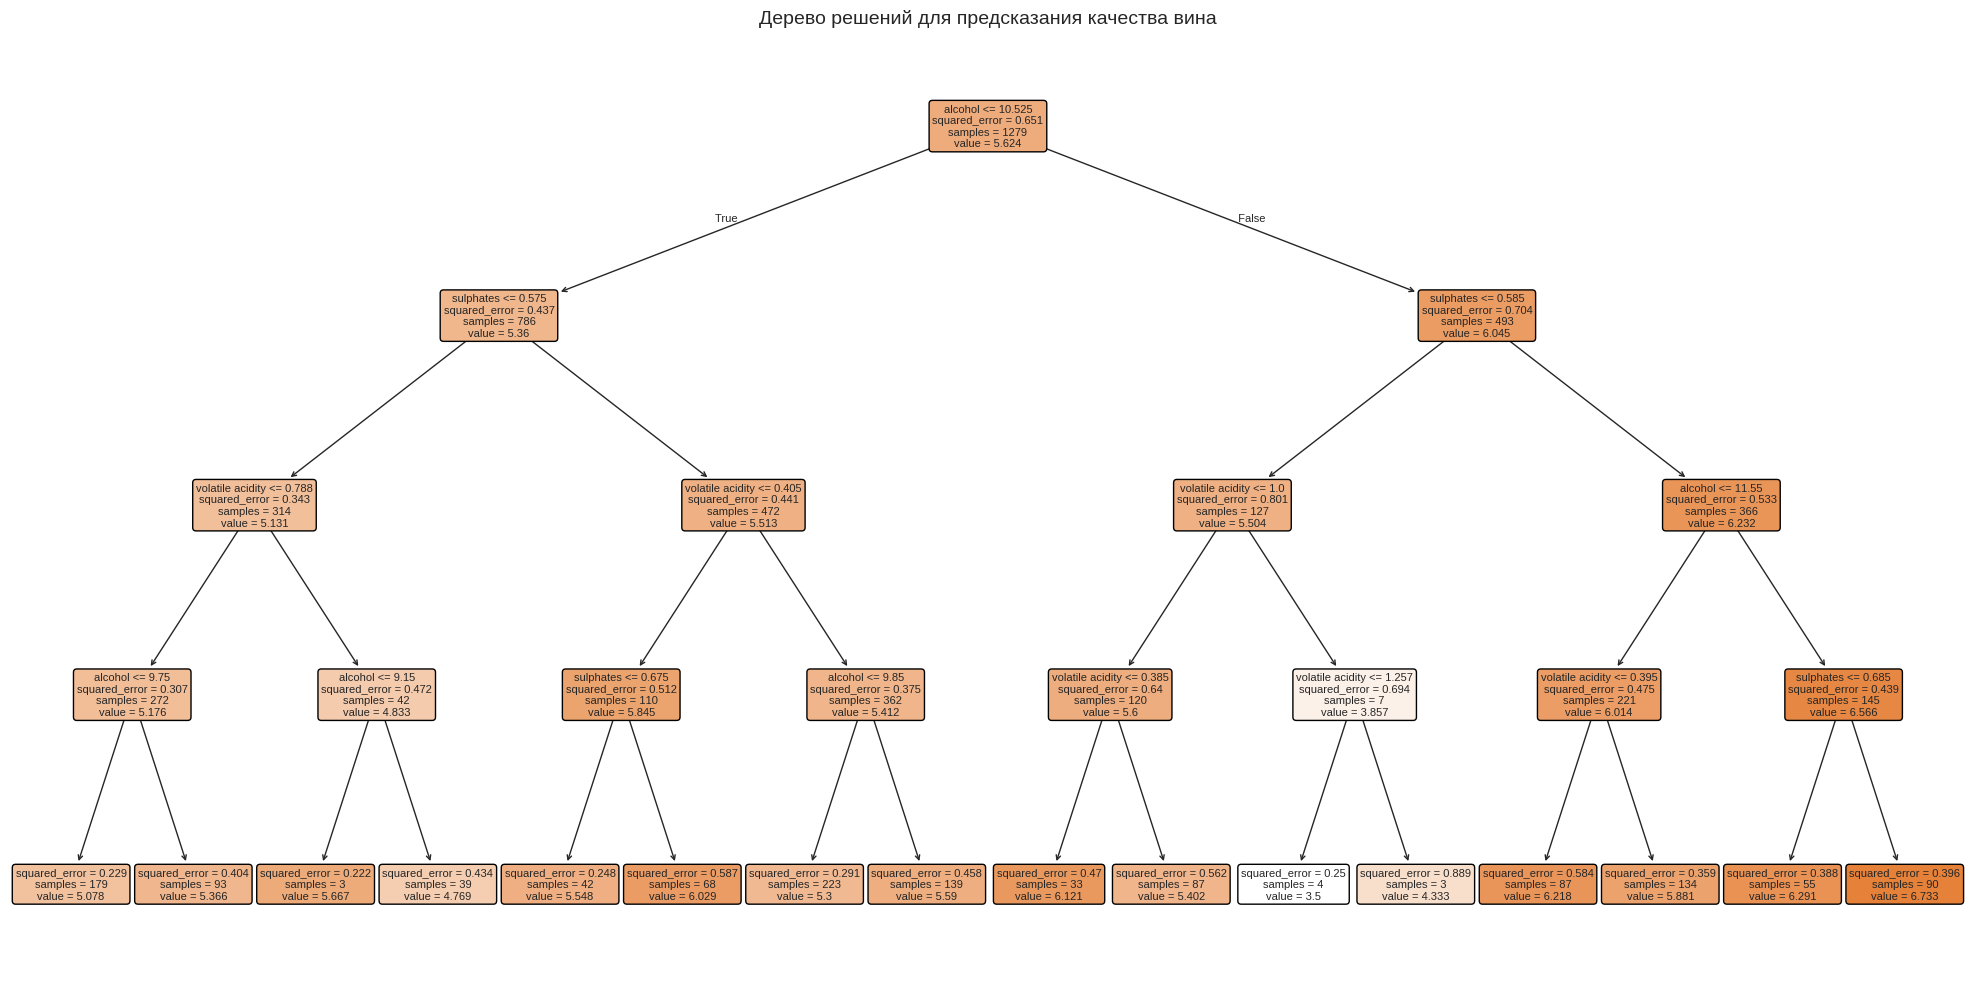

In [ ]:
# 4.10. Дерево решений (регрессия)
from sklearn.tree import DecisionTreeRegressor, plot_tree

X_tree = df[features].values
y_tree = df['quality'].values

X_t_train, X_t_test, y_t_train, y_t_test = train_test_split(X_tree, y_tree, test_size=0.2, random_state=42)

tree_model = DecisionTreeRegressor(max_depth=4, random_state=42)
tree_model.fit(X_t_train, y_t_train)
y_tree_pred = tree_model.predict(X_t_test)

print("Дерево решений (регрессия):")
print(f"  R²: {r2_score(y_t_test, y_tree_pred):.4f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_t_test, y_tree_pred)):.4f}")

# Визуализация
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(tree_model, feature_names=features, filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Дерево решений для предсказания качества вина', fontsize=14)
plt.tight_layout()
plt.show()

---

## Итоговый отчет

In [ ]:
# Сводная таблица всех элементов
elements = {
    'Тема 1: Введение в анализ данных': [
        '1. Импорт библиотек',
        '2. Загрузка данных (CSV из интернета)',
        '3. Просмотр данных (head)',
        '4. Информация о данных (dtypes, isnull)',
        '5. Описательная статистика (describe)',
        '6. Фильтрация и добавление столбцов',
        '7. Сохранение данных (to_csv)',
        '8. Группировка (groupby)',
        '9. Применение функций (apply)',
        '10. Сводные таблицы (pivot_table)'
    ],
    'Тема 2: Описательный анализ данных': [
        '1. Гистограмма (plt.hist)',
        '2. Гистограмма с KDE (sns.histplot)',
        '3. Boxplot (sns.boxplot)',
        '4. Violinplot (sns.violinplot)',
        '5. Проверка нормальности (KDE, Shapiro)',
        '6. Расширенная статистика (skew, kurtosis)',
        '7. Частотный анализ (value_counts)',
        '8. Столбчатая диаграмма (bar)',
        '9. Круговая диаграмма (pie)',
        '10. Попарные графики (pairplot)'
    ],
    'Тема 3: Исследование взаимосвязей': [
        '1. Корреляционная матрица (heatmap)',
        '2. Scatter с линией регрессии (regplot)',
        '3. Корреляции Пирсона и Спирмана',
        '4. Таблица сопряженности (crosstab)',
        '5. Тест хи-квадрат',
        '6. Тепловая карта сопряженности',
        '7. Независимый t-тест',
        '8. ANOVA (f_oneway)',
        '9. Непараметрические тесты',
        '10. Совместный график (jointplot)'
    ],
    'Тема 4: Регрессия': [
        '1. Простая линейная регрессия',
        '2. Метрики (MSE, RMSE, MAE, R²)',
        '3. Визуализация регрессии',
        '4. Множественная регрессия',
        '5. statsmodels OLS',
        '6. Анализ остатков',
        '7. VIF (мультиколлинеарность)',
        '8. Сравнение моделей',
        '9. Полиномиальная регрессия',
        '10. Дерево решений'
    ]
}

print("="*70)
print("ИТОГОВАЯ ТАБЛИЦА ЭЛЕМЕНТОВ ПРОЕКТА")
print("="*70)
total = 0
for theme, items in elements.items():
    print(f"\n{theme}:")
    print("-"*60)
    for item in items:
        print(f"  ✓ {item}")
        total += 1

print(f"\n{'='*70}")
print(f"ВСЕГО ЭЛЕМЕНТОВ: {total}")
print("="*70)

ИТОГОВАЯ ТАБЛИЦА ЭЛЕМЕНТОВ ПРОЕКТА

Тема 1: Введение в анализ данных:
------------------------------------------------------------
  ✓ 1. Импорт библиотек
  ✓ 2. Загрузка данных (CSV из интернета)
  ✓ 3. Просмотр данных (head)
  ✓ 4. Информация о данных (dtypes, isnull)
  ✓ 5. Описательная статистика (describe)
  ✓ 6. Фильтрация и добавление столбцов
  ✓ 7. Сохранение данных (to_csv)
  ✓ 8. Группировка (groupby)
  ✓ 9. Применение функций (apply)
  ✓ 10. Сводные таблицы (pivot_table)

Тема 2: Описательный анализ данных:
------------------------------------------------------------
  ✓ 1. Гистограмма (plt.hist)
  ✓ 2. Гистограмма с KDE (sns.histplot)
  ✓ 3. Boxplot (sns.boxplot)
  ✓ 4. Violinplot (sns.violinplot)
  ✓ 5. Проверка нормальности (KDE, Shapiro)
  ✓ 6. Расширенная статистика (skew, kurtosis)
  ✓ 7. Частотный анализ (value_counts)
  ✓ 8. Столбчатая диаграмма (bar)
  ✓ 9. Круговая диаграмма (pie)
  ✓ 10. Попарные графики (pairplot)

Тема 3: Исследование взаимосвязей:
------------